# Imports & Function Definition

In [1]:
import numpy as np
import torch
from intrinsics_dimension import twonn_pytorch
import os
import yaml
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

In [2]:
def parse_layer(layer_num: int):
    path = f'{DIRNAME}/layer_{layer_num:02d}'
    batches = []
    for filename in os.listdir(path):
        filepath = f"{path}/{filename}"
        batch = np.load(filepath).astype('float64')
        #batch = np.load(filepath)[:, -1, :] # last hidden from seq_len
        batches.append(batch)
    batches = np.concatenate(batches, axis=0) # [batch_size, emd_dim]
    return batches

In [3]:
def calculate_anisotropy_svd(X, center=False):
    """
    Calculate anisotropy using SVD as defined in the paper.
    
    Anisotropy is computed as the ratio of the largest squared singular value
    to the sum of all squared singular values of the centered embedding matrix.
    
    Args:
        X: numpy array of shape (num_samples, embedding_dim)
        center: whether to center the embeddings (subtract mean)
    
    Returns:
        anisotropy: scalar value between 0 and 1
                   (higher = more anisotropic)
    """
    # Center the embeddings (subtract mean)
    if center:
        X_centered = X - np.mean(X, axis=0, keepdims=True)
    else:
        X_centered = X
    
    # Perform SVD: X = U @ diag(S) @ V^T
    # We only need singular values
    from scipy.linalg import svd
    U, singular_values, Vt = svd(X_centered, full_matrices=False)
    
    # Compute anisotropy = σ₁² / Σᵢ σᵢ²
    sigma_squared = singular_values ** 2
    anisotropy = sigma_squared[0] / np.sum(sigma_squared)
    
    return anisotropy

In [4]:
def parse_twonn_dimention(layer : int,
                    num_samples : int = 8):
    A = torch.Tensor(parse_layer(layer))[:num_samples]
    dim = twonn_pytorch(A)
    return float(dim)

In [5]:
def parse_anisotropy(layer : int,
                     num_samples : int = 8):
    X = parse_layer(layer)[:num_samples]
    return float(calculate_anisotropy_svd(X))

In [6]:
def parse_singular_dimention(layer : int,
                             num_samples : int,
                             variance_threshold=0.90):
    X = parse_layer(layer)[:num_samples]
    # Вычисляем SVD разложение
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    
    # Вычисляем квадраты сингулярных чисел (дисперсии)
    variance = S ** 2
    
    # Вычисляем общую дисперсию
    total_variance = np.sum(variance)
    
    # Вычисляем кумулятивную дисперсию
    cumulative_variance = np.cumsum(variance) / total_variance
    
    # Находим минимальное k
    k = np.argmax(cumulative_variance >= variance_threshold) + 1
    
    return float(k)

In [7]:
def get_relative_depth(arr):
    return np.arange(len(arr))/len(arr)

In [42]:
def plot_model_metric(metric, model_stats, title=None):
    """Plot a metric from stats dictionaries across all models."""
    
    fig, ax = plt.subplots(figsize=(10, 5))
    for model_name in model_stats.keys():
        ax.plot(get_relative_depth(model_stats[model_name][metric]), model_stats[model_name][metric], label = f'{model_name}')

    
    ax.set(xlabel='layer', ylabel='dim')
    if title:
        ax.set_title(title)
    else:
        ax.set_title(metric)
    ax.grid()
    ax.legend()
    plt.show()
    plt.close()

In [43]:
def plot_model_dims(stats, title=None):
    """Plot a metric from stats dictionaries across all models."""
    
    fig, ax = plt.subplots(figsize=(10, 5))
    for metric in ['singular_dim_09', 'singular_dim_095', 'singular_dim_099', 'singular_dim_0999']:
        ax.plot(get_relative_depth(stats[metric]), stats[metric], label = f'{metric[13:]}')
    
    ax.set(xlabel='layer', ylabel='dim', yscale='log')
    if title:
        ax.set_title(title)
    ax.grid()
    ax.legend()
    plt.show()
    plt.close()

# Stats Calculation

In [35]:
model_names = [
    # 'qwen2.5-0.5b', 
    'qwen2.5-1.5b', 
    # 'qwen3-0.6b',
    # 'qwen3-0.6b-base',
    # 'gemma-3-1b-it',
    # 'gemma-2b',
]

In [39]:
for model_name in model_names:
    stats = {
        'anisotropy': [],
        'singular_dim_09': [],
        'singular_dim_095': [],
        'singular_dim_099': [],
        'singular_dim_0999': [],
    }

    DIRNAME = f'../activation_saved/activations_math_500/{model_name}/agg_last'
    SAVE_STATS_PATH = f'../all_stats/math_500/{model_name}'
    
    for i in tqdm(range(len(os.listdir(DIRNAME)))):
        stats['anisotropy'].append(parse_anisotropy(i, num_samples=-1))
        stats['singular_dim_09'].append(parse_singular_dimention(i, num_samples=-1, variance_threshold=0.9))
        stats['singular_dim_095'].append(parse_singular_dimention(i, num_samples=-1, variance_threshold=0.95))
        stats['singular_dim_099'].append(parse_singular_dimention(i, num_samples=-1, variance_threshold=0.99))
        stats['singular_dim_0999'].append(parse_singular_dimention(i, num_samples=-1, variance_threshold=0.999))
    
    with open(f'{SAVE_STATS_PATH}.yaml', 'w') as f:
        yaml.dump(stats, f)

  0%|          | 0/29 [00:00<?, ?it/s]

# Plotting

In [10]:
model_names = [
    'qwen2.5-0.5b',     
    'qwen2.5-1.5b', 
    'qwen3-0.6b',
    'qwen3-0.6b-base',
    'gemma-3-1b-it',
    'gemma-2b',
]

In [11]:
model_stats = {}
for model_name in model_names[:]:
    with open(f'../all_stats/math_500/{model_name}.yaml', 'r') as f:
        model_stats[model_name] = yaml.safe_load(f)

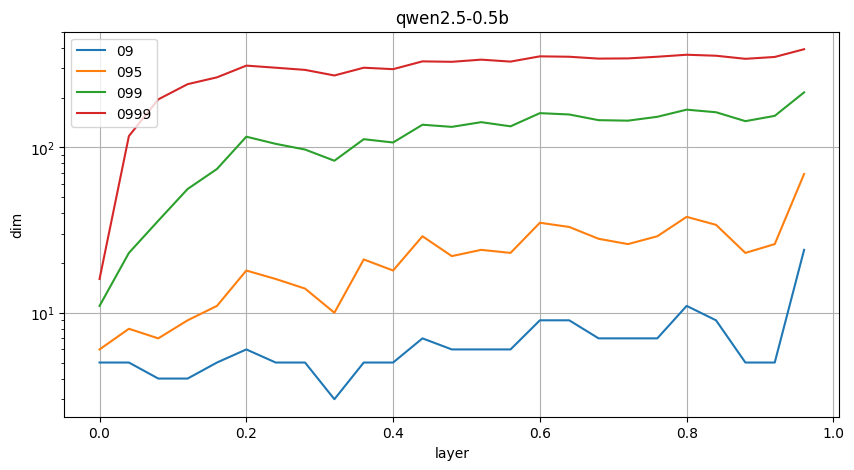

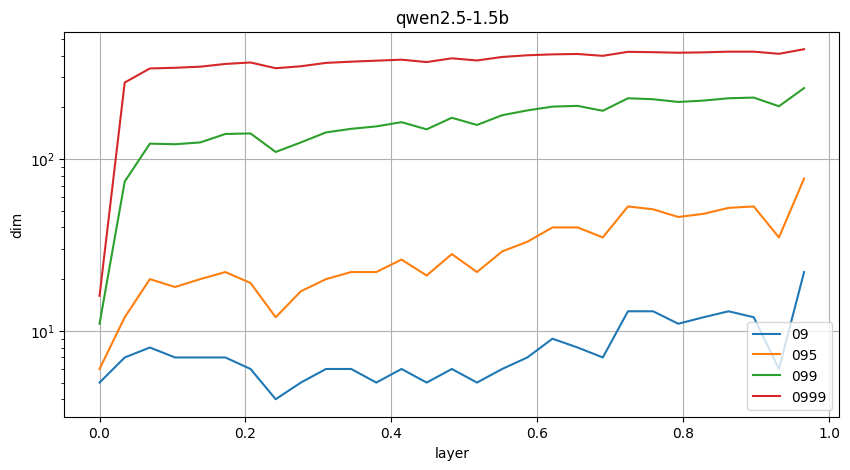

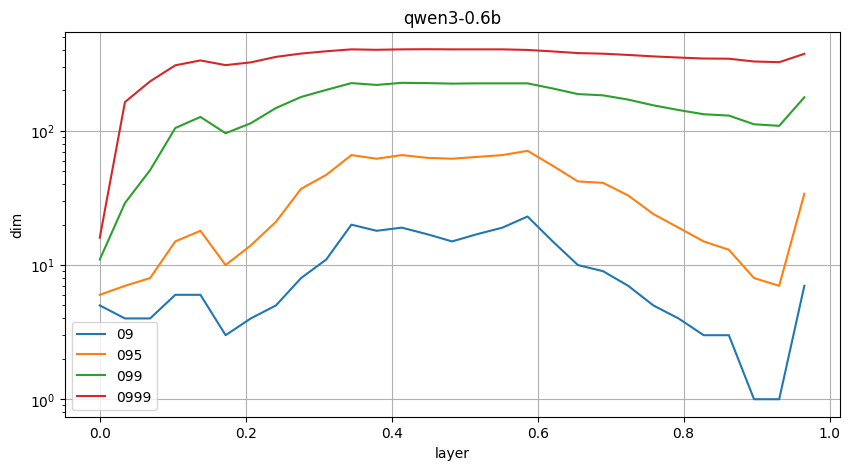

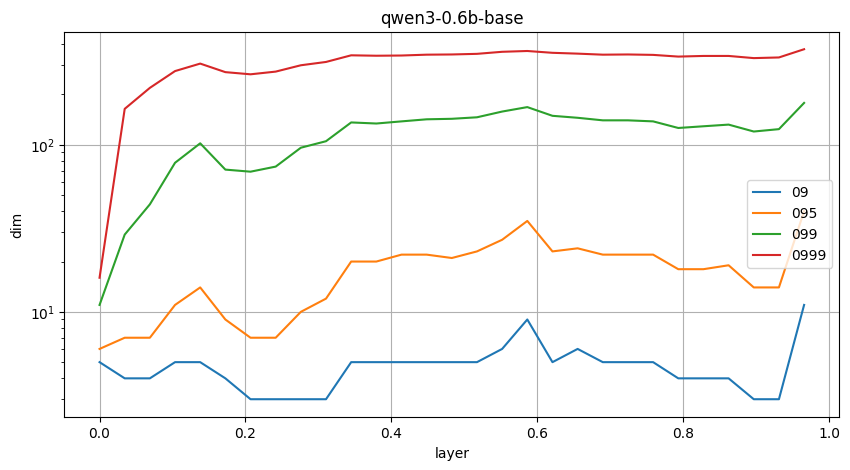

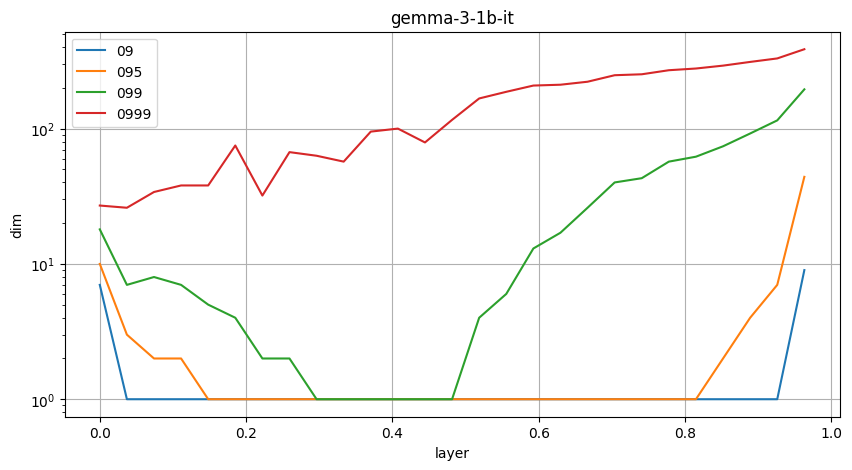

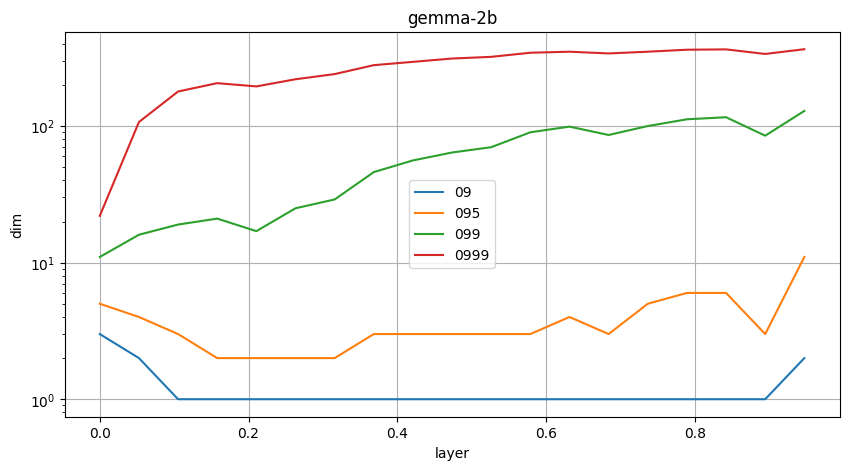

In [25]:
for model in model_names:
    plot_model_dims(model_stats[model], title=model)

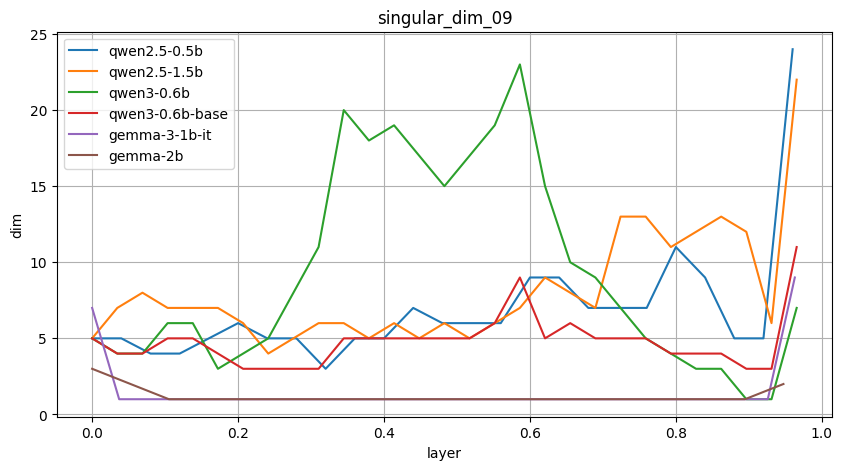

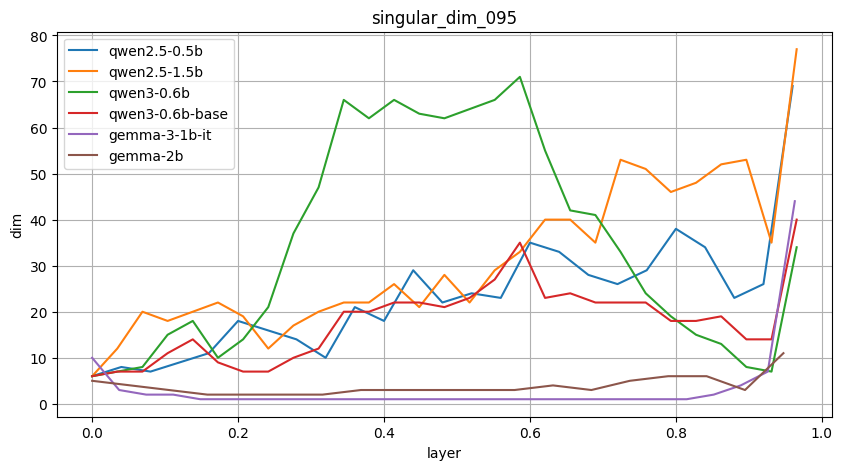

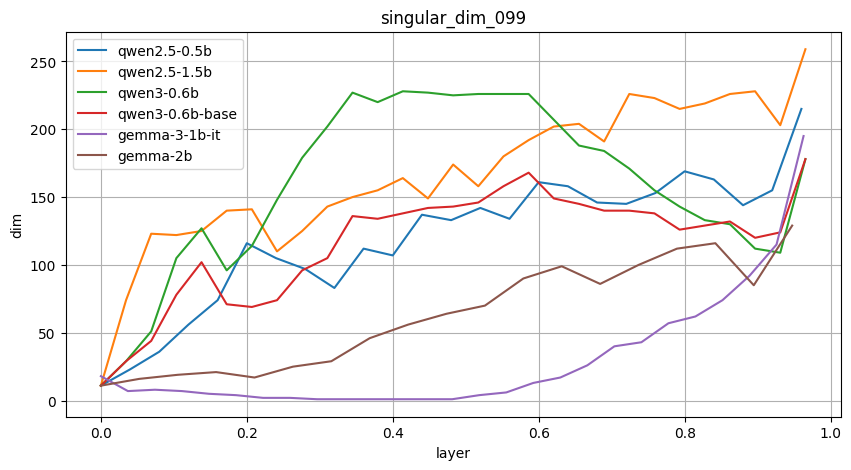

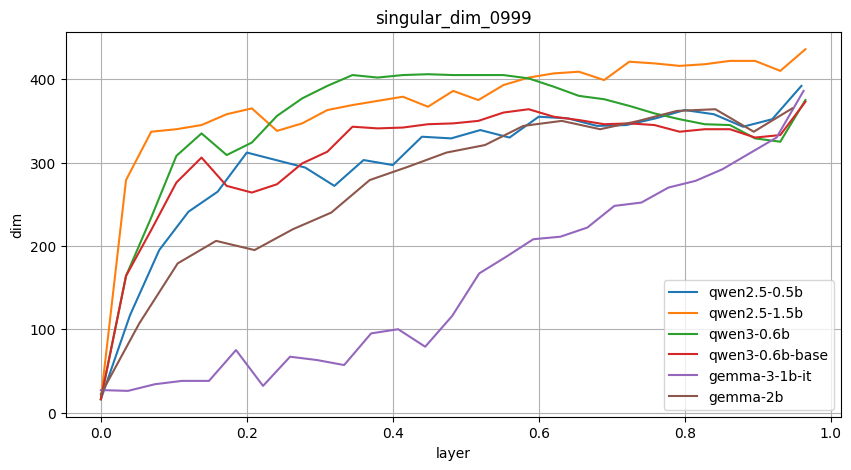

In [26]:
for metric in ['singular_dim_09', 'singular_dim_095', 'singular_dim_099', 'singular_dim_0999']:
    plot_model_metric(metric, model_stats=model_stats)

In [12]:
accs = {
    'gemma-2b': 0.14,
    'gemma-3-1b-it': 0.3,
    'qwen2.5-0.5b': 0.29,
    'qwen2.5-1.5b': 0.5,
    'qwen3-0.6b': 0.29,
    'qwen3-0.6b-base': 0.4,
}

In [17]:
hidden_dim = {
    'gemma-2b': 2048,
    'gemma-3-1b-it': 1152,
    'qwen2.5-0.5b': 896,
    'qwen2.5-1.5b': 1536,
    'qwen3-0.6b': 1024,
    'qwen3-0.6b-base': 1024,
}

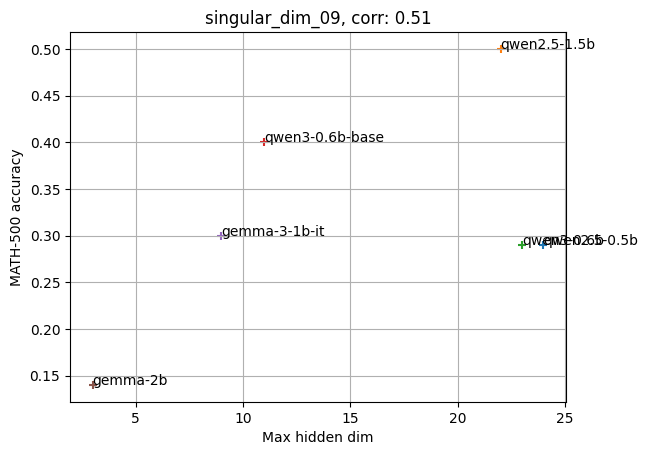

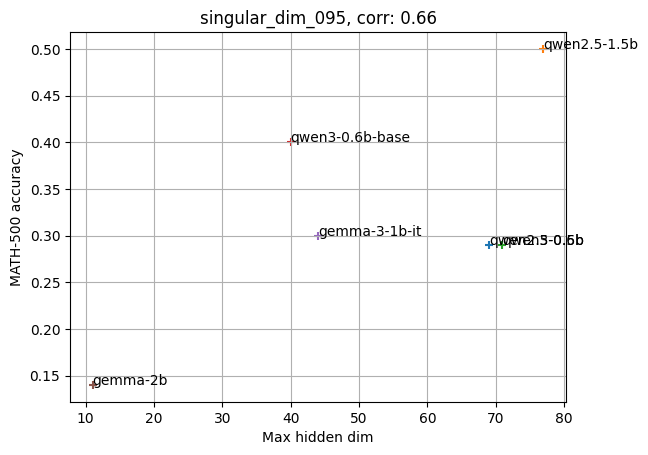

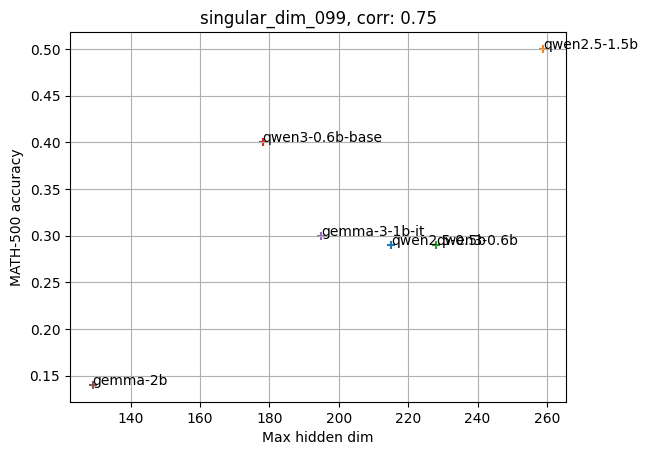

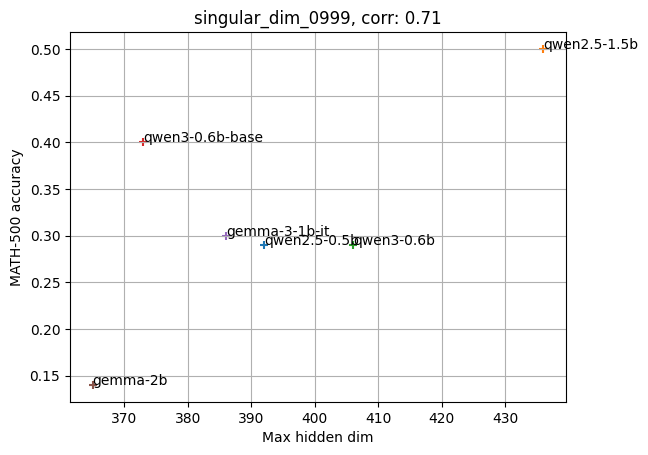

In [14]:
for metric in ['singular_dim_09', 'singular_dim_095', 'singular_dim_099', 'singular_dim_0999']:
    for i, model in enumerate(model_names):
        plt.scatter(np.max(model_stats[model][metric]), accs[model], marker='+')
        plt.text(np.max(model_stats[model][metric]), accs[model], model)
    plt.grid()
    plt.ylabel('MATH-500 accuracy')
    plt.xlabel('Max hidden dim')
    max_dims = np.array([np.max(model_stats[model][metric]) for model in model_names])
    model_accs = np.array([accs[model] for model in model_names])
    plt.title(f'{metric}, corr: {np.corrcoef(max_dims, model_accs)[0, 1]:.2f}')
    plt.show()
    plt.close()

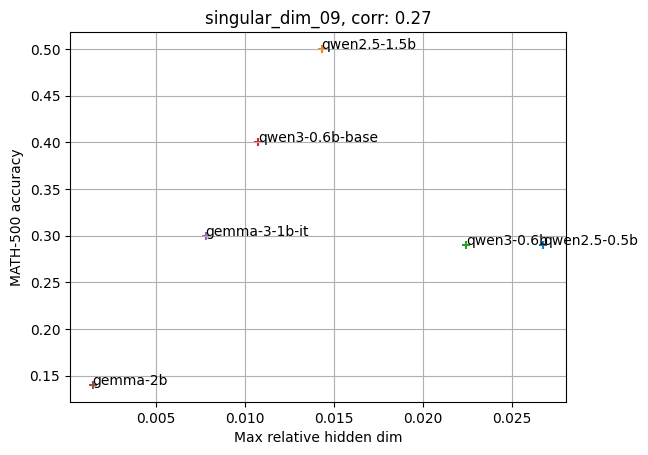

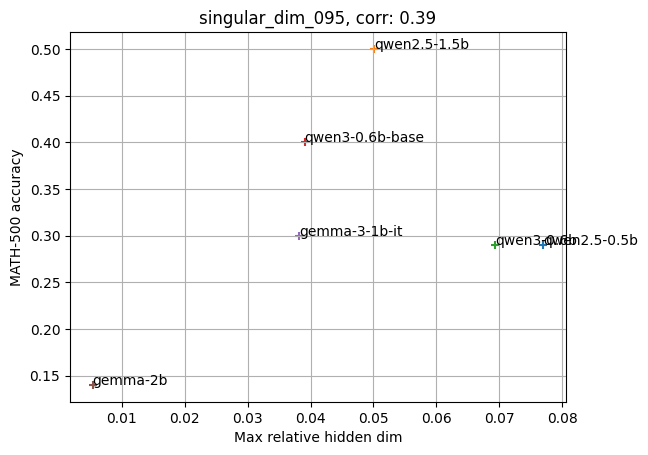

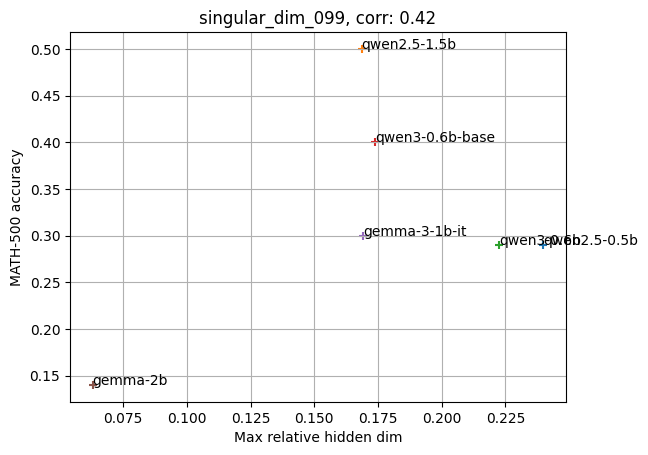

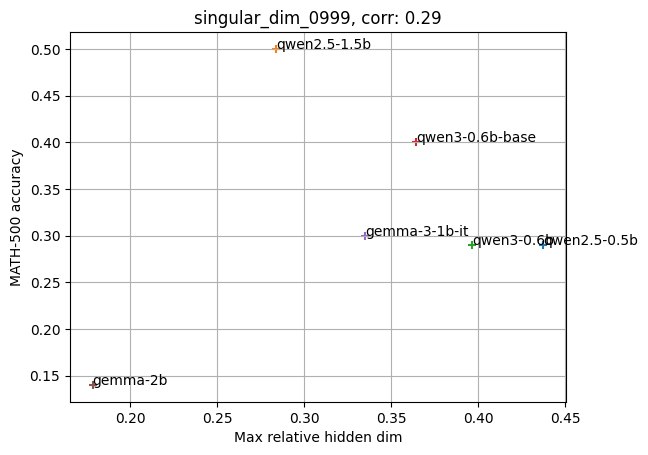

In [18]:
# Relative
for metric in ['singular_dim_09', 'singular_dim_095', 'singular_dim_099', 'singular_dim_0999']:
    for i, model in enumerate(model_names):
        plt.scatter(np.max(model_stats[model][metric]) / hidden_dim[model], accs[model], marker='+')
        plt.text(np.max(model_stats[model][metric]) / hidden_dim[model], accs[model], model)
    plt.grid()
    plt.ylabel('MATH-500 accuracy')
    plt.xlabel('Max relative hidden dim')
    max_dims = np.array([np.max(model_stats[model][metric]) / hidden_dim[model] for model in model_names])
    model_accs = np.array([accs[model] for model in model_names])
    plt.title(f'{metric}, corr: {np.corrcoef(max_dims, model_accs)[0, 1]:.2f}')
    plt.show()
    plt.close()

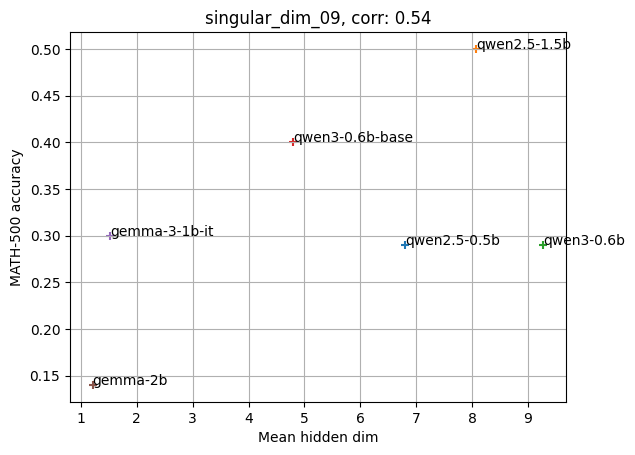

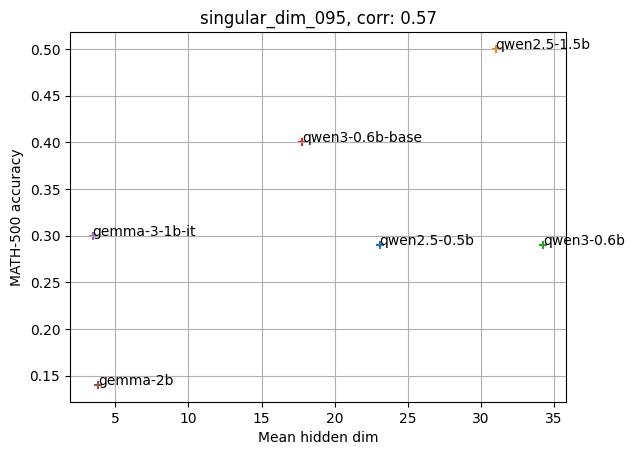

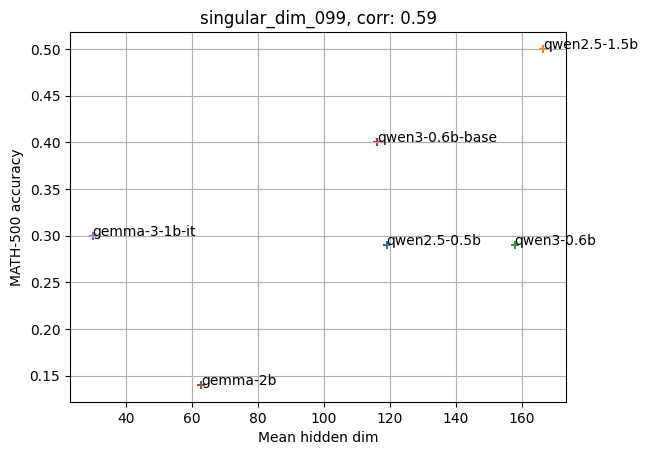

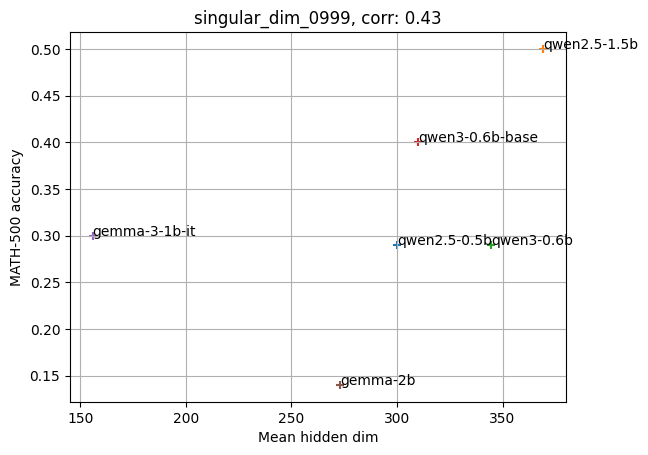

In [29]:
for metric in ['singular_dim_09', 'singular_dim_095', 'singular_dim_099', 'singular_dim_0999']:
    for i, model in enumerate(model_names):
        plt.scatter(np.mean(model_stats[model][metric]), accs[model], marker='+')
        plt.text(np.mean(model_stats[model][metric]), accs[model], model)
    plt.grid()
    plt.ylabel('MATH-500 accuracy')
    plt.xlabel('Mean hidden dim')
    mean_dims = np.array([np.mean(model_stats[model][metric]) for model in model_names])
    model_accs = np.array([accs[model] for model in model_names])
    plt.title(f'{metric}, corr: {np.corrcoef(mean_dims, model_accs)[0, 1]:.2f}')
    plt.show()
    plt.close()

## With prompt

In [31]:
model_names = [
    # 'qwen2.5-0.5b', 
    # 'qwen2.5-1.5b', 
    # 'qwen3-0.6b',
    'qwen3-0.6b-base',
    # 'gemma-3-1b-it',
    # 'gemma-2b',
]

In [32]:
for model_name in model_names:
    stats = {
        'anisotropy': [],
        'singular_dim_09': [],
        'singular_dim_095': [],
        'singular_dim_099': [],
        'singular_dim_0999': [],
    }

    DIRNAME = f'../activation_saved/activations_math_500_w_prompt/{model_name}/agg_last'
    SAVE_STATS_PATH = f'../all_stats/math_500_w_prompt/{model_name}'
    
    for i in tqdm(range(len(os.listdir(DIRNAME)))):
        stats['anisotropy'].append(parse_anisotropy(i, num_samples=-1))
        stats['singular_dim_09'].append(parse_singular_dimention(i, num_samples=-1, variance_threshold=0.9))
        stats['singular_dim_095'].append(parse_singular_dimention(i, num_samples=-1, variance_threshold=0.95))
        stats['singular_dim_099'].append(parse_singular_dimention(i, num_samples=-1, variance_threshold=0.99))
        stats['singular_dim_0999'].append(parse_singular_dimention(i, num_samples=-1, variance_threshold=0.999))
    
    with open(f'{SAVE_STATS_PATH}.yaml', 'w') as f:
        yaml.dump(stats, f)

  0%|          | 0/29 [00:00<?, ?it/s]

# Plotting

In [41]:
model_names = [
    'qwen2.5-0.5b',     
    'qwen2.5-1.5b', 
    'qwen3-0.6b',
    'qwen3-0.6b-base',
    'gemma-3-1b-it',
    'gemma-2b',
]

In [34]:
model_stats = {}
for model_name in model_names[:]:
    with open(f'../all_stats/math_500_w_prompt/{model_name}.yaml', 'r') as f:
        model_stats[model_name] = yaml.safe_load(f)

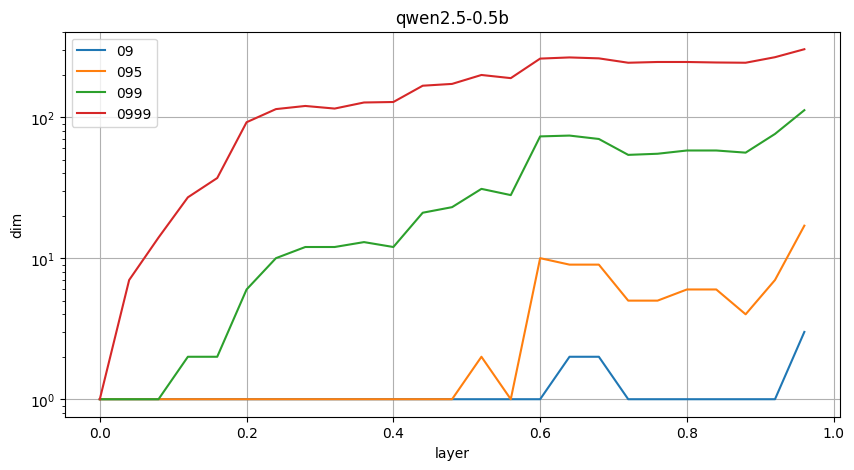

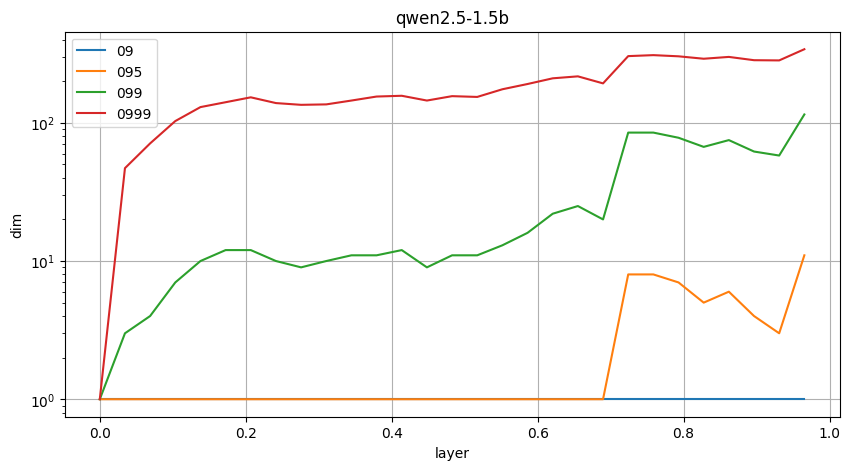

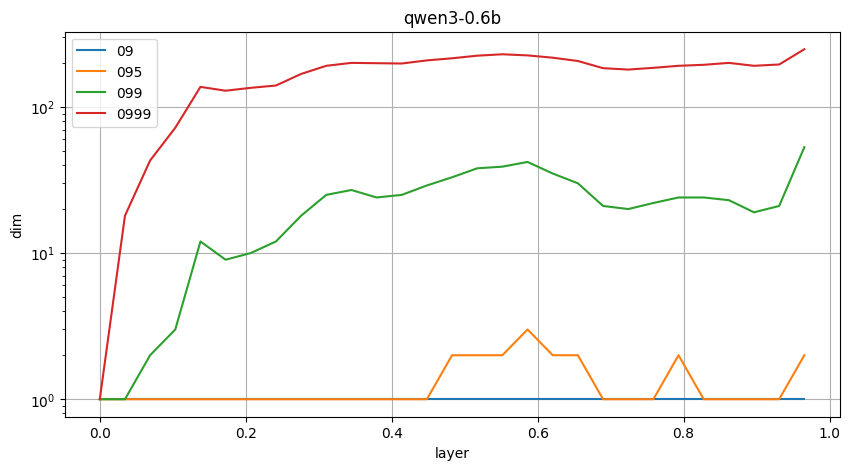

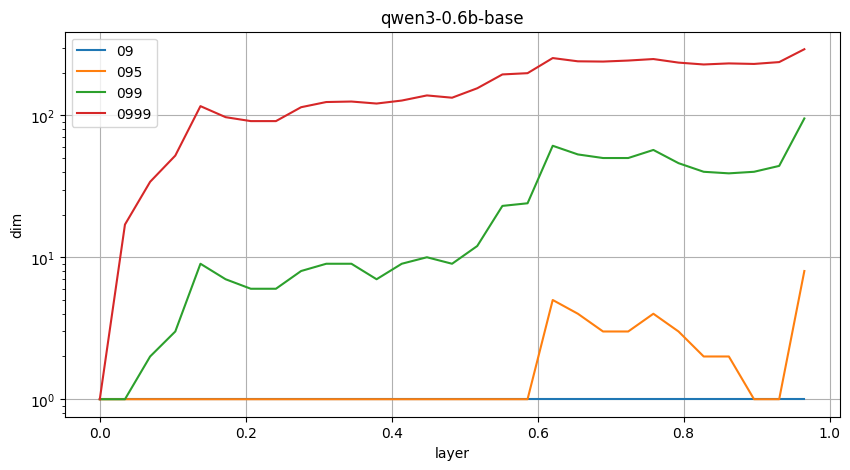

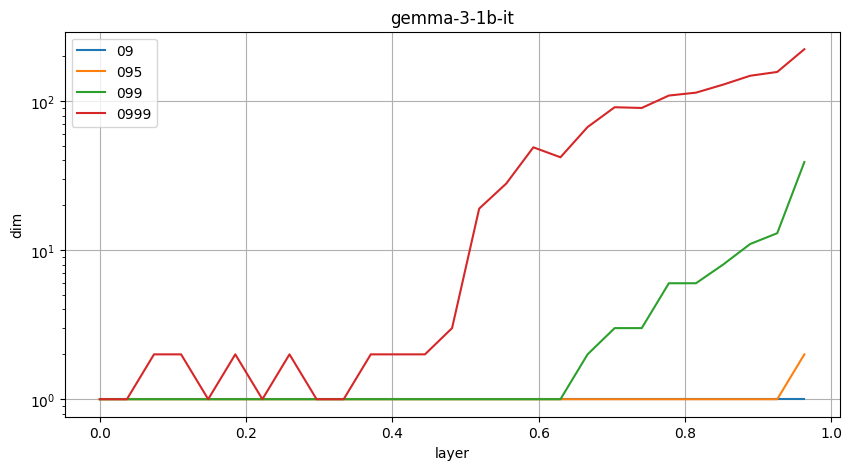

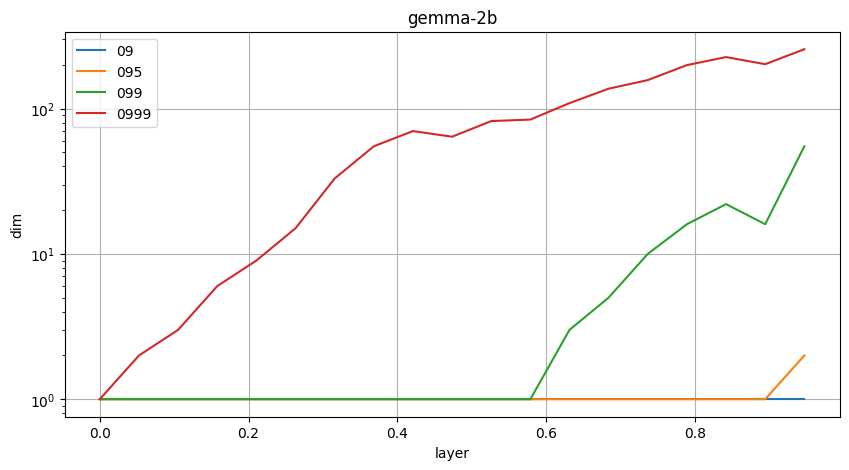

In [35]:
for model in model_names:
    plot_model_dims(model_stats[model], title=model)

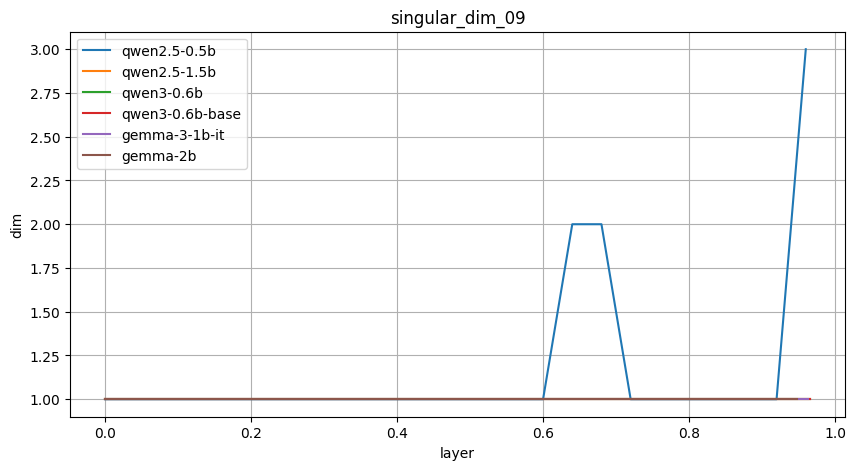

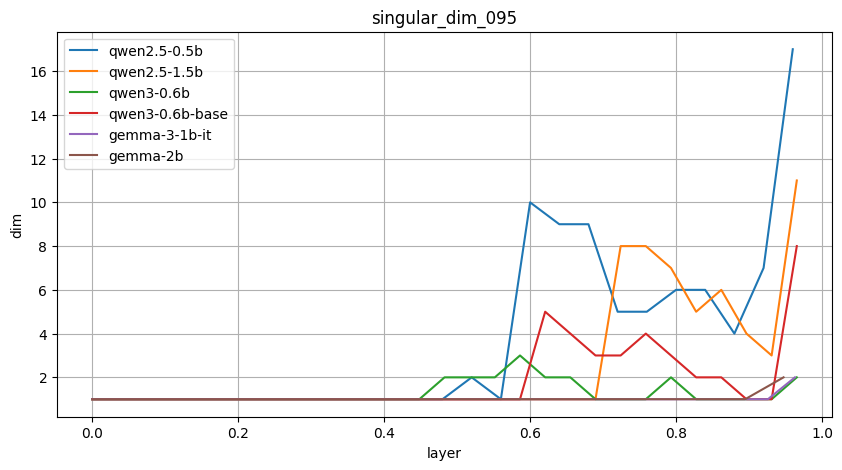

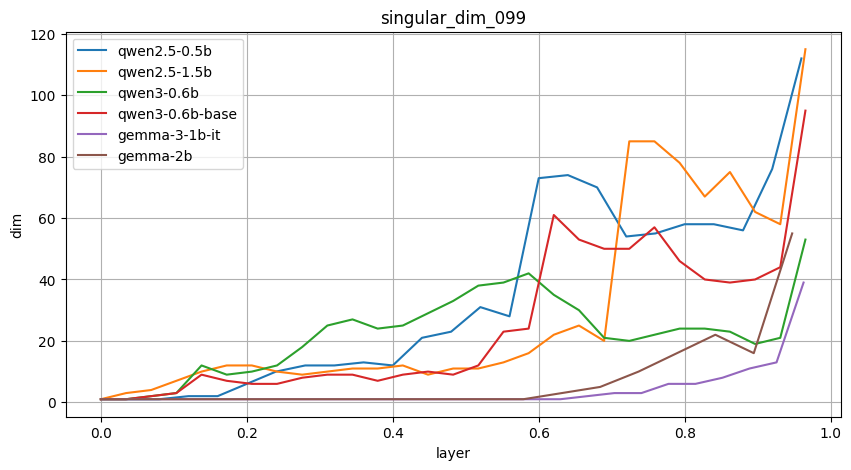

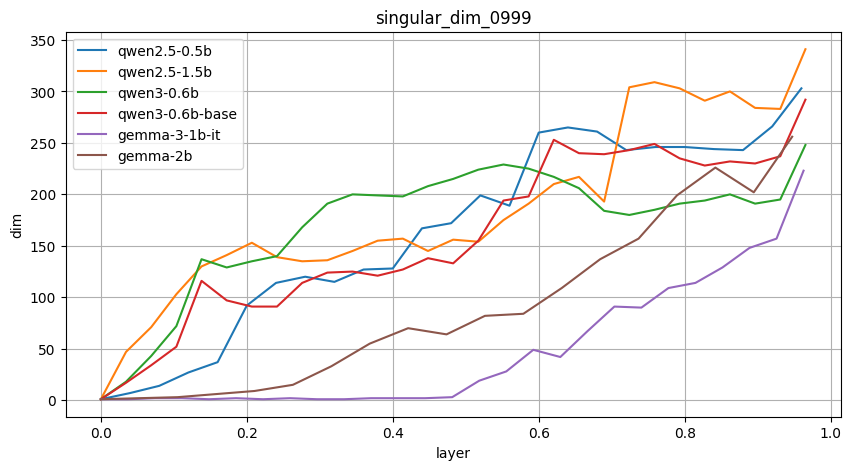

In [36]:
for metric in ['singular_dim_09', 'singular_dim_095', 'singular_dim_099', 'singular_dim_0999']:
    plot_model_metric(metric, model_stats=model_stats)

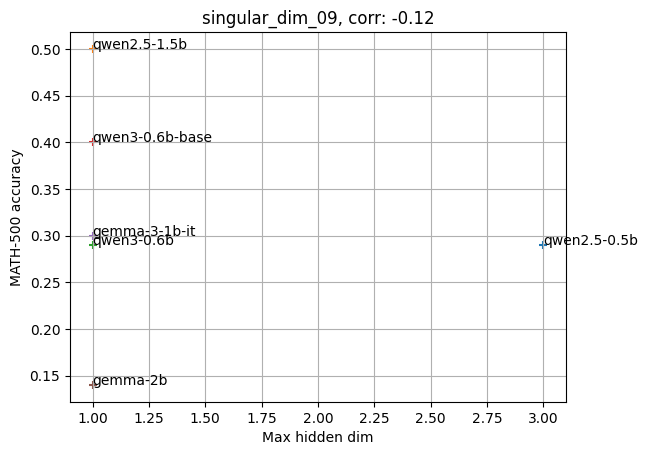

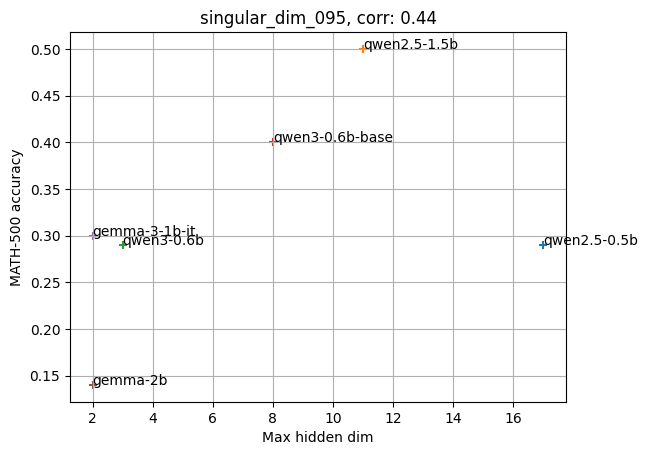

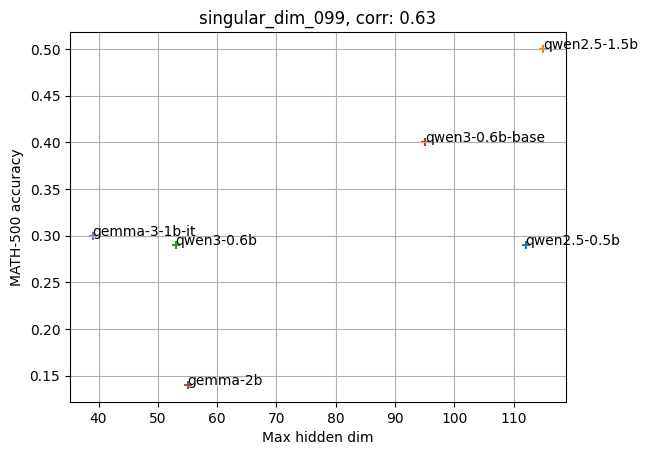

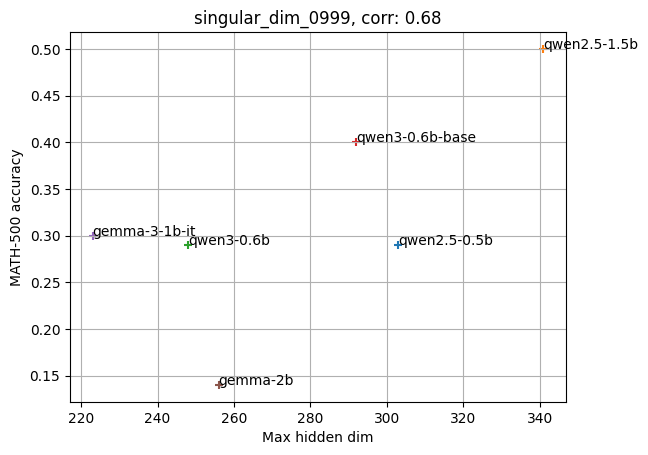

In [44]:
# Max
for metric in ['singular_dim_09', 'singular_dim_095', 'singular_dim_099', 'singular_dim_0999']:
    for i, model in enumerate(model_names):
        plt.scatter(np.max(model_stats[model][metric]), accs[model], marker='+')
        plt.text(np.max(model_stats[model][metric]), accs[model], model)
    plt.grid()
    plt.ylabel('MATH-500 accuracy')
    plt.xlabel('Max hidden dim')
    max_dims = np.array([np.max(model_stats[model][metric]) for model in model_names])
    model_accs = np.array([accs[model] for model in model_names])
    plt.title(f'{metric}, corr: {np.corrcoef(max_dims, model_accs)[0, 1]:.2f}')
    plt.show()
    plt.close()

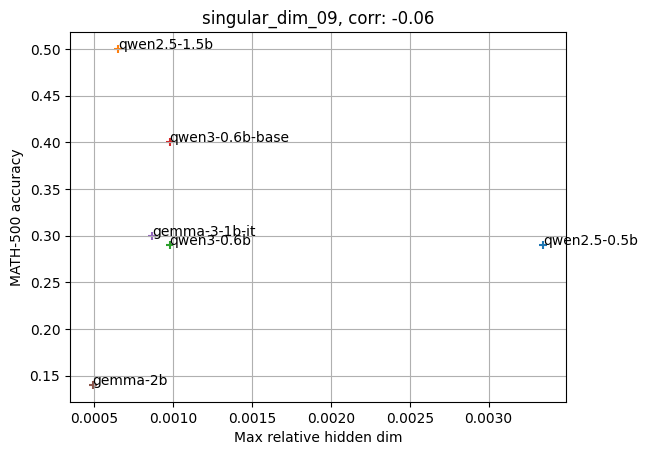

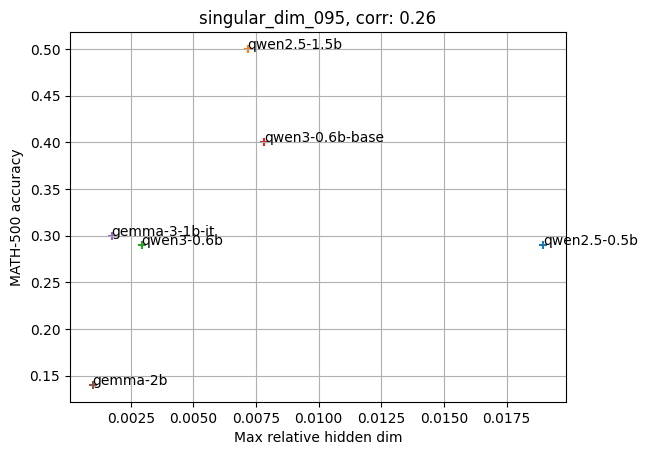

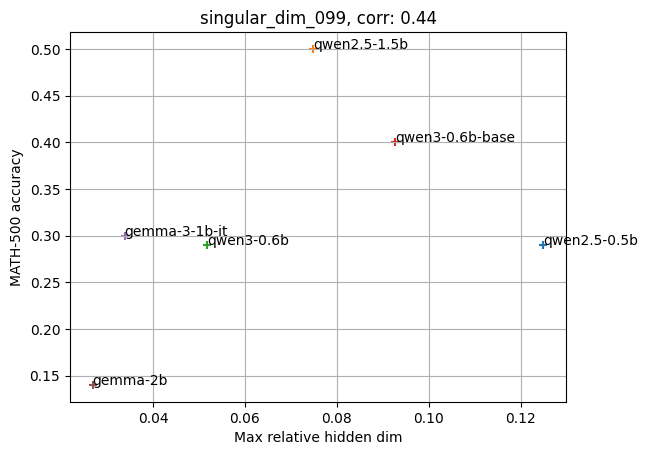

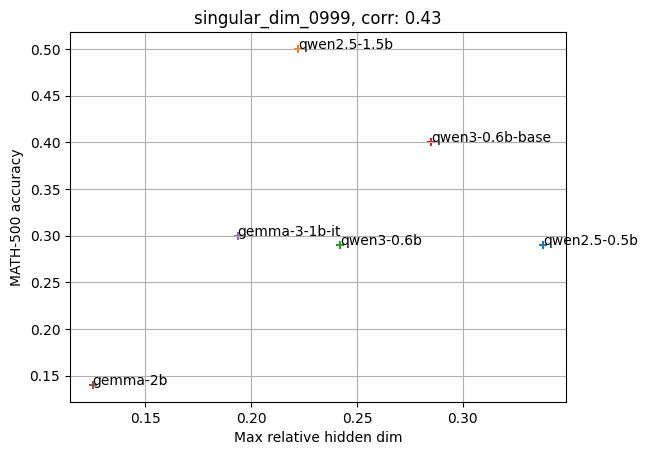

In [45]:
# Max relative
for metric in ['singular_dim_09', 'singular_dim_095', 'singular_dim_099', 'singular_dim_0999']:
    for i, model in enumerate(model_names):
        plt.scatter(np.max(model_stats[model][metric]) / hidden_dim[model], accs[model], marker='+')
        plt.text(np.max(model_stats[model][metric]) / hidden_dim[model], accs[model], model)
    plt.grid()
    plt.ylabel('MATH-500 accuracy')
    plt.xlabel('Max relative hidden dim')
    max_dims = np.array([np.max(model_stats[model][metric]) / hidden_dim[model] for model in model_names])
    model_accs = np.array([accs[model] for model in model_names])
    plt.title(f'{metric}, corr: {np.corrcoef(max_dims, model_accs)[0, 1]:.2f}')
    plt.show()
    plt.close()

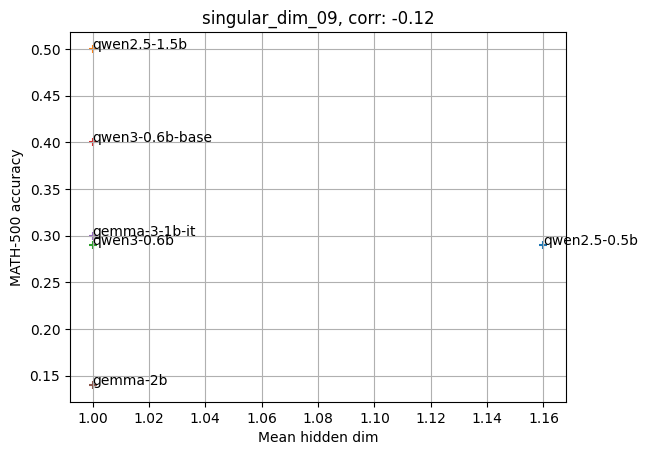

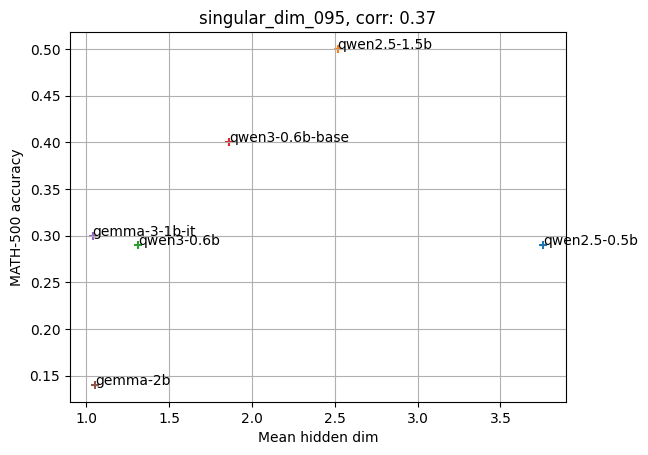

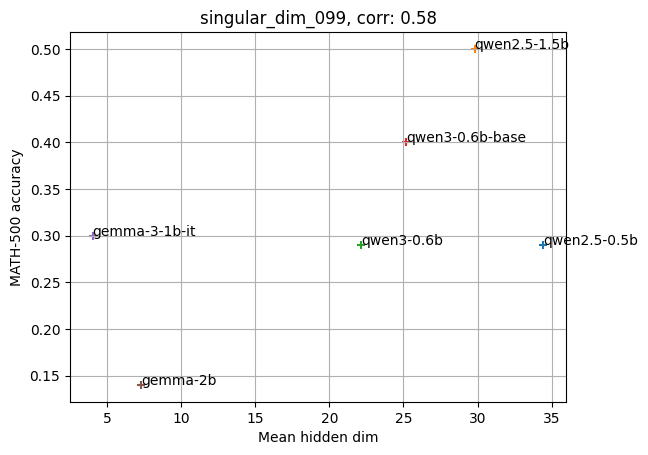

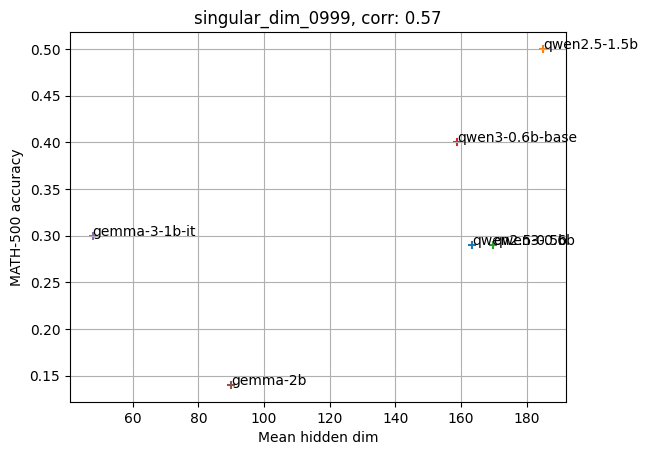

In [39]:
# Mean
for metric in ['singular_dim_09', 'singular_dim_095', 'singular_dim_099', 'singular_dim_0999']:
    for i, model in enumerate(model_names):
        plt.scatter(np.mean(model_stats[model][metric]), accs[model], marker='+')
        plt.text(np.mean(model_stats[model][metric]), accs[model], model)
    plt.grid()
    plt.ylabel('MATH-500 accuracy')
    plt.xlabel('Mean hidden dim')
    mean_dims = np.array([np.mean(model_stats[model][metric]) for model in model_names])
    model_accs = np.array([accs[model] for model in model_names])
    plt.title(f'{metric}, corr: {np.corrcoef(mean_dims, model_accs)[0, 1]:.2f}')
    plt.show()
    plt.close()

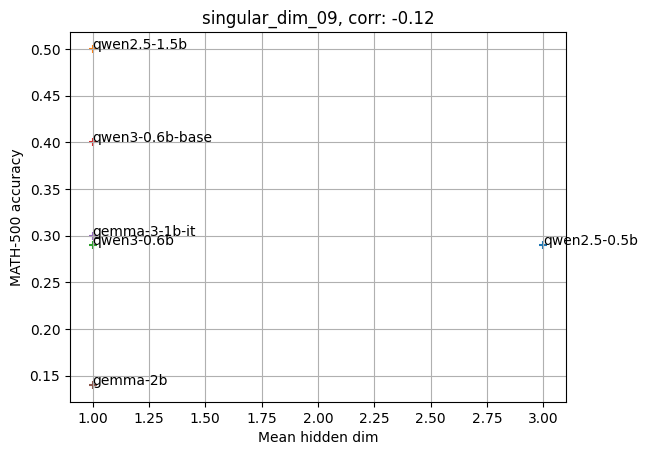

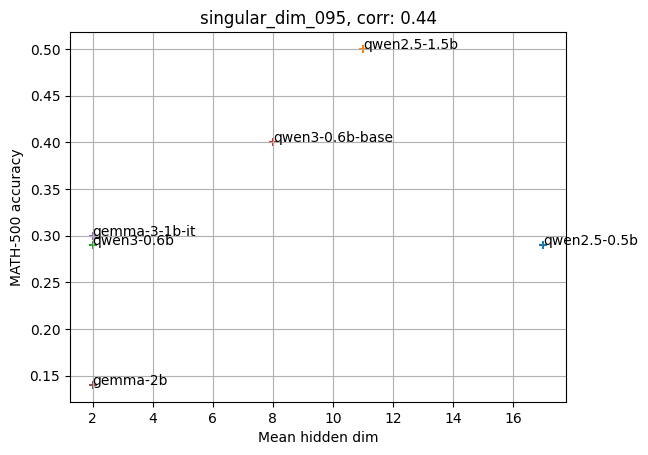

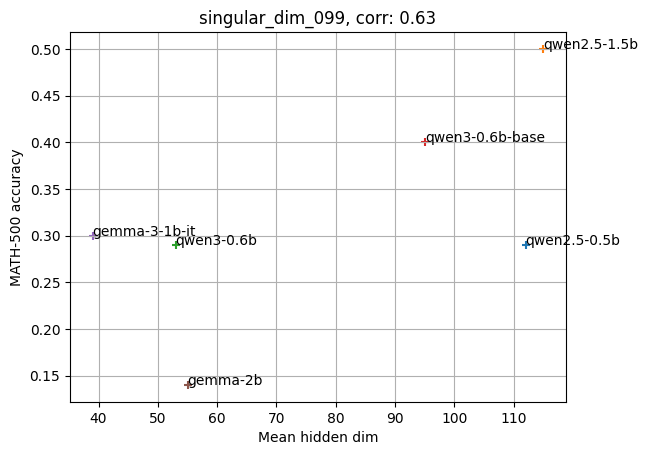

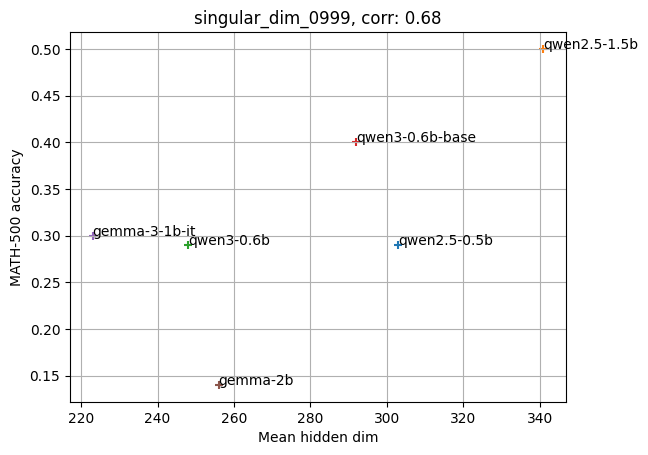

In [46]:
# Last
for metric in ['singular_dim_09', 'singular_dim_095', 'singular_dim_099', 'singular_dim_0999']:
    for i, model in enumerate(model_names):
        plt.scatter(model_stats[model][metric][-1], accs[model], marker='+')
        plt.text(model_stats[model][metric][-1], accs[model], model)
    plt.grid()
    plt.ylabel('MATH-500 accuracy')
    plt.xlabel('Mean hidden dim')
    last_dims = np.array([model_stats[model][metric][-1] for model in model_names])
    model_accs = np.array([accs[model] for model in model_names])
    plt.title(f'{metric}, corr: {np.corrcoef(last_dims, model_accs)[0, 1]:.2f}')
    plt.show()
    plt.close()

## Token mean with prompt

In [47]:
model_names = [
    'qwen2.5-0.5b', 
    'qwen2.5-1.5b', 
    'qwen3-0.6b',
    'qwen3-0.6b-base',
    'gemma-3-1b-it',
    'gemma-2b',
]

In [48]:
for model_name in model_names:
    stats = {
        'anisotropy': [],
        'singular_dim_09': [],
        'singular_dim_095': [],
        'singular_dim_099': [],
        'singular_dim_0999': [],
    }

    DIRNAME = f'../activation_saved/activations_math_500_w_prompt/{model_name}/agg_mean'
    SAVE_STATS_PATH = f'../all_stats/math_500_w_prompt/{model_name}'
    
    for i in tqdm(range(len(os.listdir(DIRNAME)))):
        stats['anisotropy'].append(parse_anisotropy(i, num_samples=-1))
        stats['singular_dim_09'].append(parse_singular_dimention(i, num_samples=-1, variance_threshold=0.9))
        stats['singular_dim_095'].append(parse_singular_dimention(i, num_samples=-1, variance_threshold=0.95))
        stats['singular_dim_099'].append(parse_singular_dimention(i, num_samples=-1, variance_threshold=0.99))
        stats['singular_dim_0999'].append(parse_singular_dimention(i, num_samples=-1, variance_threshold=0.999))
    
    with open(f'{SAVE_STATS_PATH}.yaml', 'w') as f:
        yaml.dump(stats, f)

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/29 [00:00<?, ?it/s]

  0%|          | 0/29 [00:00<?, ?it/s]

  0%|          | 0/29 [00:00<?, ?it/s]

  0%|          | 0/27 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

# Plotting

In [41]:
model_names = [
    'qwen2.5-0.5b',     
    'qwen2.5-1.5b', 
    'qwen3-0.6b',
    'qwen3-0.6b-base',
    'gemma-3-1b-it',
    'gemma-2b',
]

In [49]:
model_stats = {}
for model_name in model_names[:]:
    with open(f'../all_stats/math_500_w_prompt/{model_name}.yaml', 'r') as f:
        model_stats[model_name] = yaml.safe_load(f)

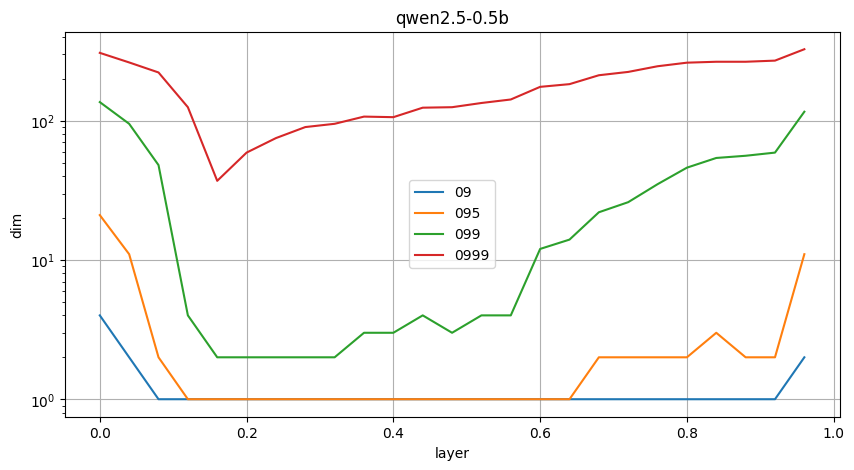

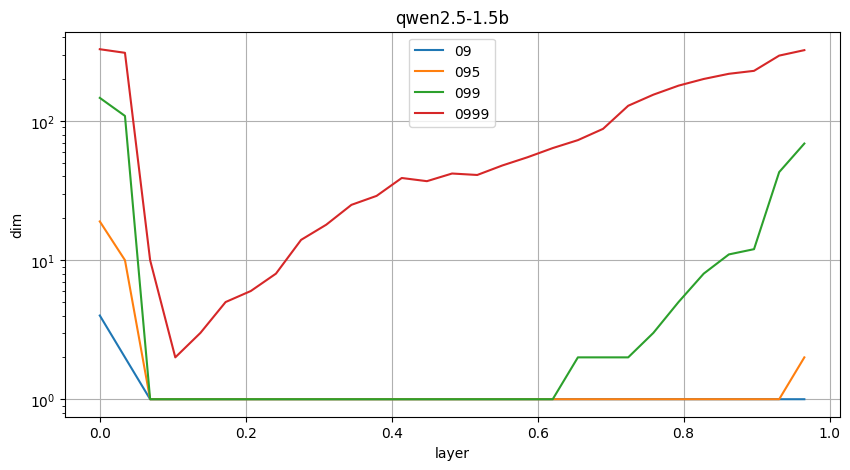

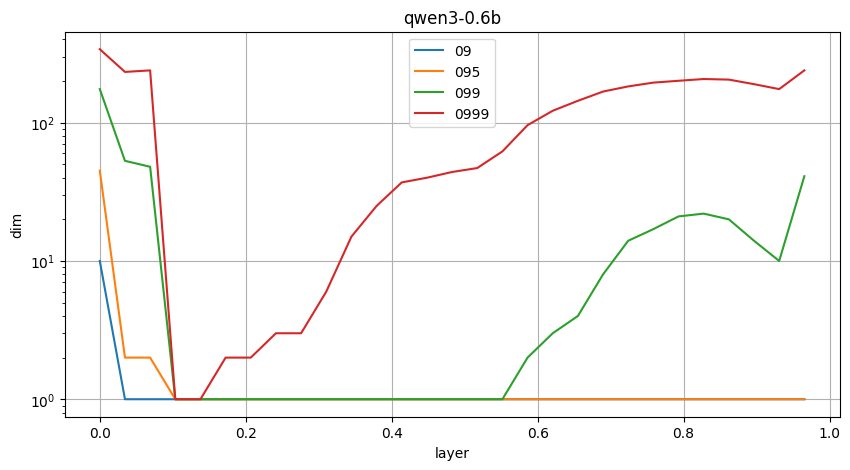

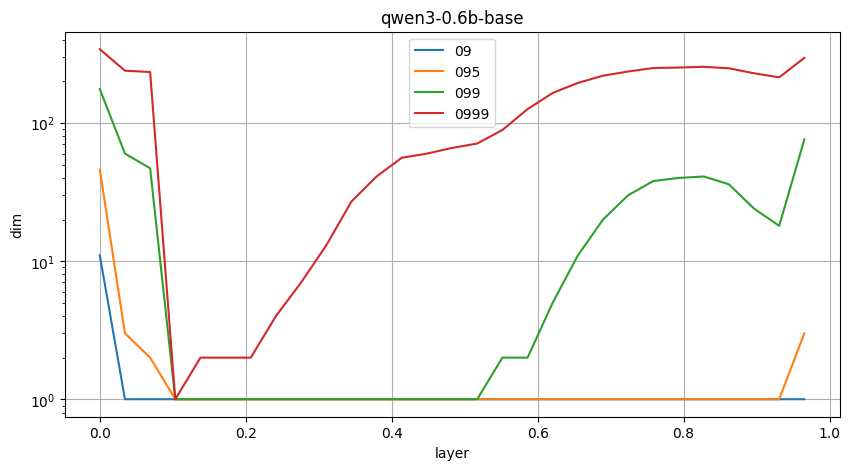

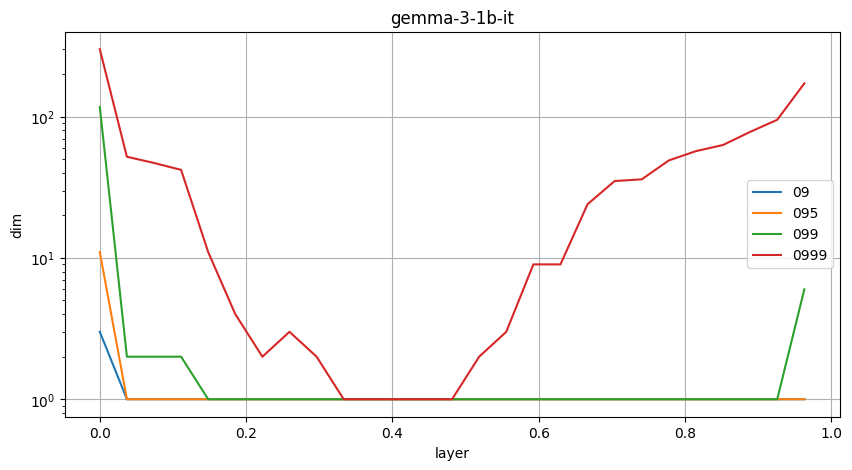

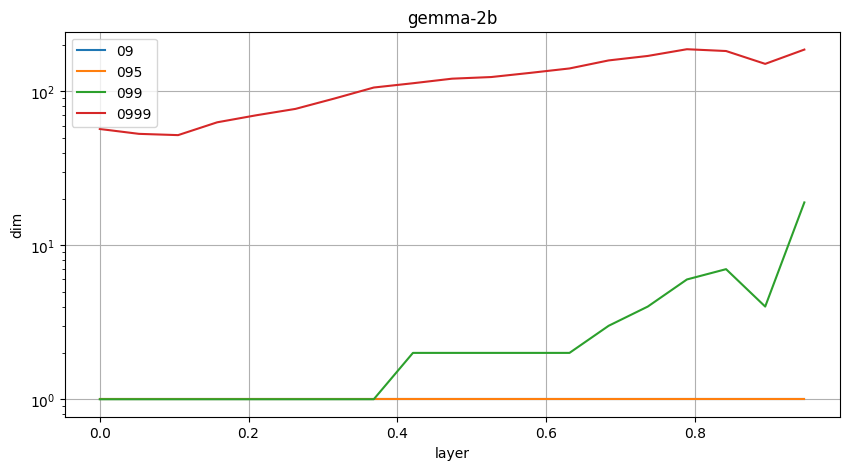

In [50]:
for model in model_names:
    plot_model_dims(model_stats[model], title=model)

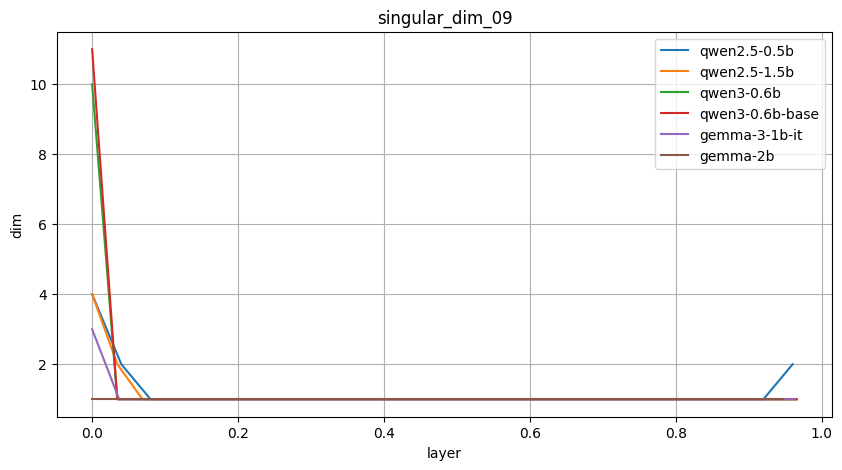

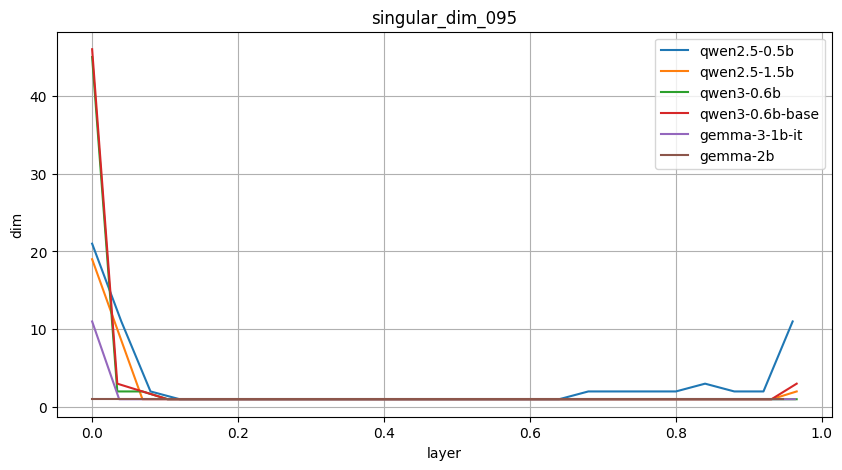

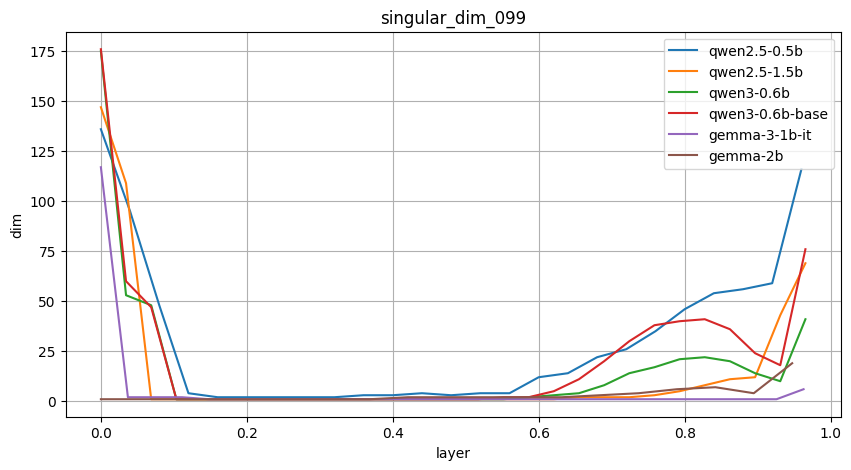

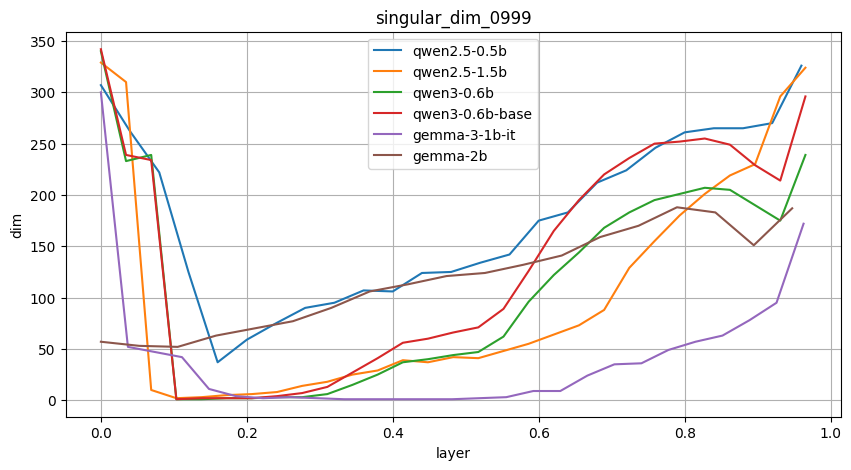

In [51]:
for metric in ['singular_dim_09', 'singular_dim_095', 'singular_dim_099', 'singular_dim_0999']:
    plot_model_metric(metric, model_stats=model_stats)

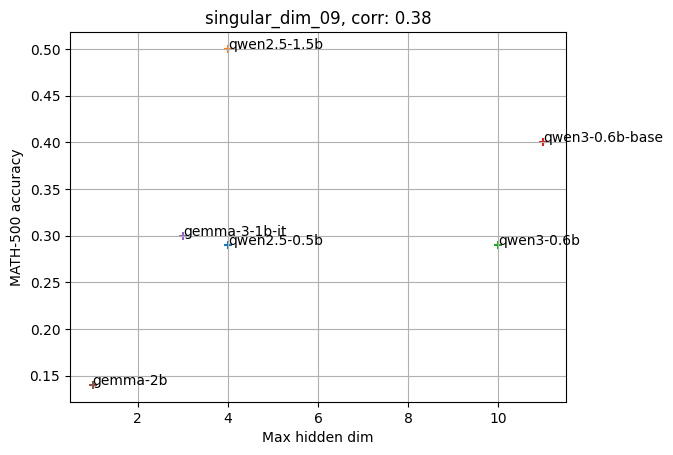

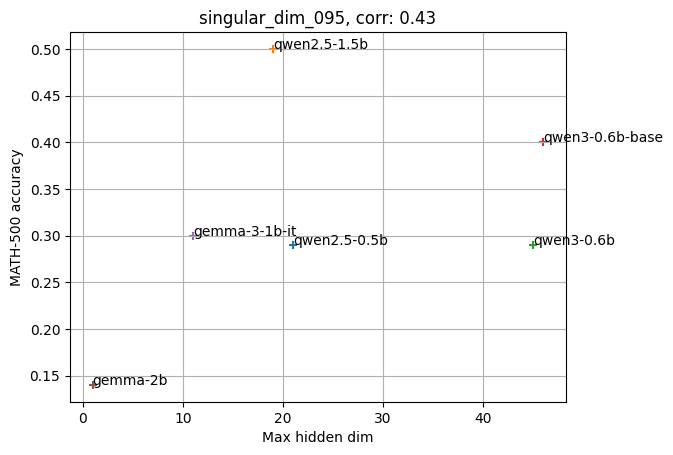

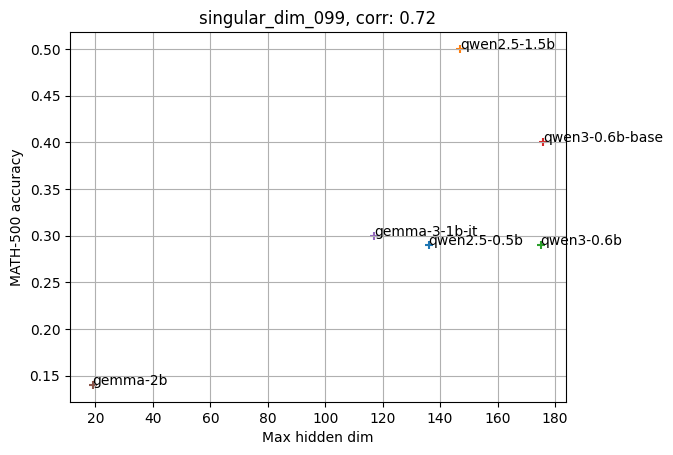

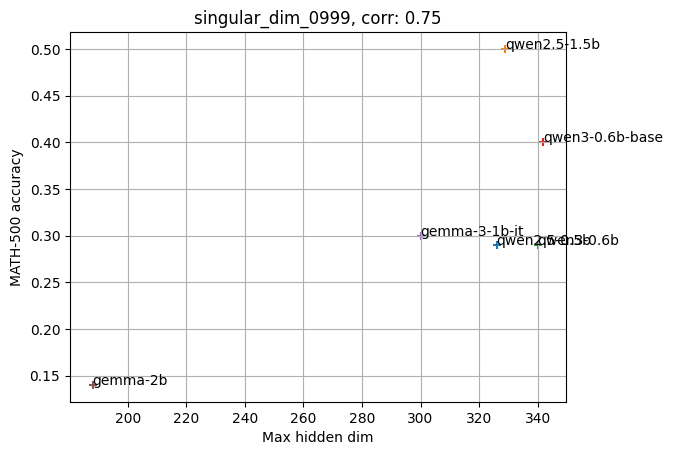

In [52]:
# Max
for metric in ['singular_dim_09', 'singular_dim_095', 'singular_dim_099', 'singular_dim_0999']:
    for i, model in enumerate(model_names):
        plt.scatter(np.max(model_stats[model][metric]), accs[model], marker='+')
        plt.text(np.max(model_stats[model][metric]), accs[model], model)
    plt.grid()
    plt.ylabel('MATH-500 accuracy')
    plt.xlabel('Max hidden dim')
    max_dims = np.array([np.max(model_stats[model][metric]) for model in model_names])
    model_accs = np.array([accs[model] for model in model_names])
    plt.title(f'{metric}, corr: {np.corrcoef(max_dims, model_accs)[0, 1]:.2f}')
    plt.show()
    plt.close()

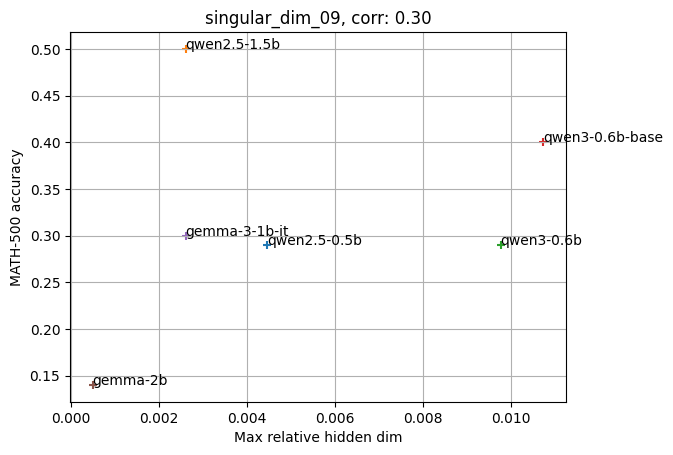

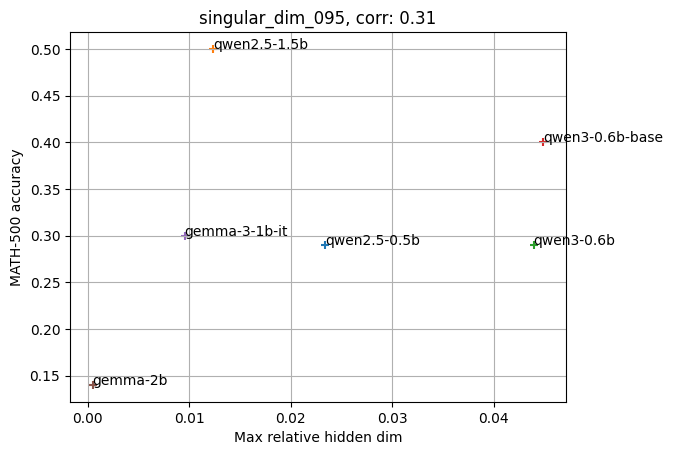

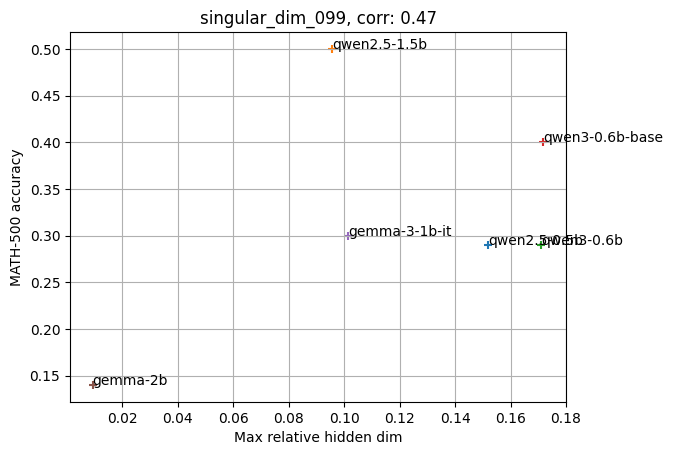

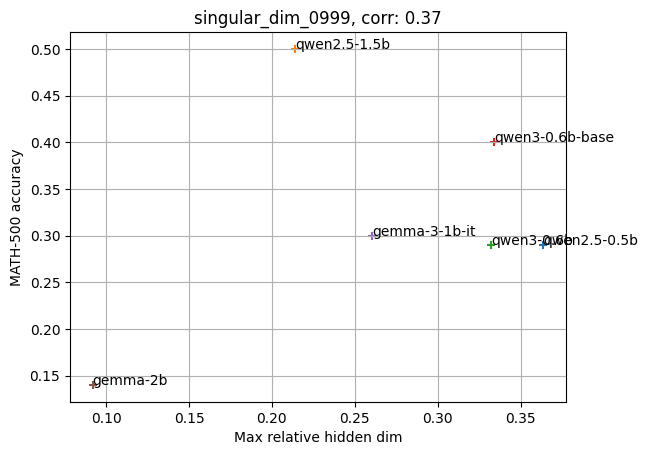

In [53]:
# Max relative
for metric in ['singular_dim_09', 'singular_dim_095', 'singular_dim_099', 'singular_dim_0999']:
    for i, model in enumerate(model_names):
        plt.scatter(np.max(model_stats[model][metric]) / hidden_dim[model], accs[model], marker='+')
        plt.text(np.max(model_stats[model][metric]) / hidden_dim[model], accs[model], model)
    plt.grid()
    plt.ylabel('MATH-500 accuracy')
    plt.xlabel('Max relative hidden dim')
    max_dims = np.array([np.max(model_stats[model][metric]) / hidden_dim[model] for model in model_names])
    model_accs = np.array([accs[model] for model in model_names])
    plt.title(f'{metric}, corr: {np.corrcoef(max_dims, model_accs)[0, 1]:.2f}')
    plt.show()
    plt.close()

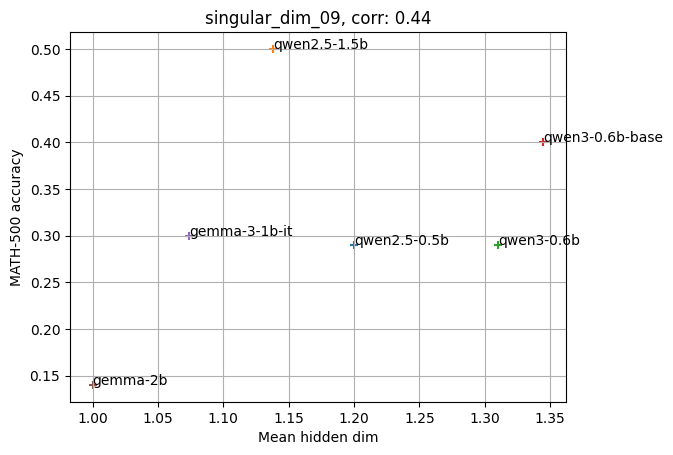

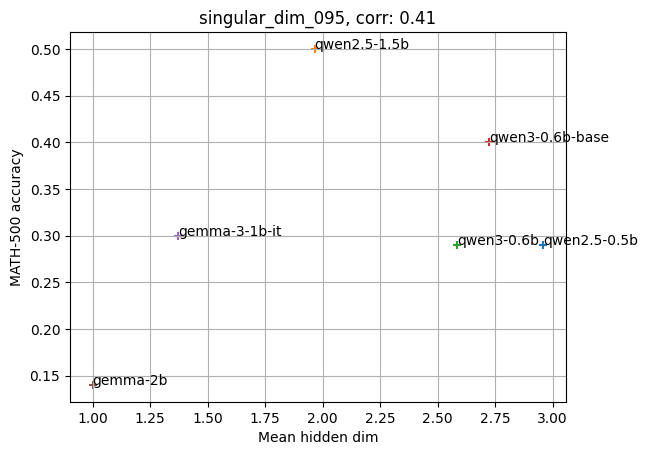

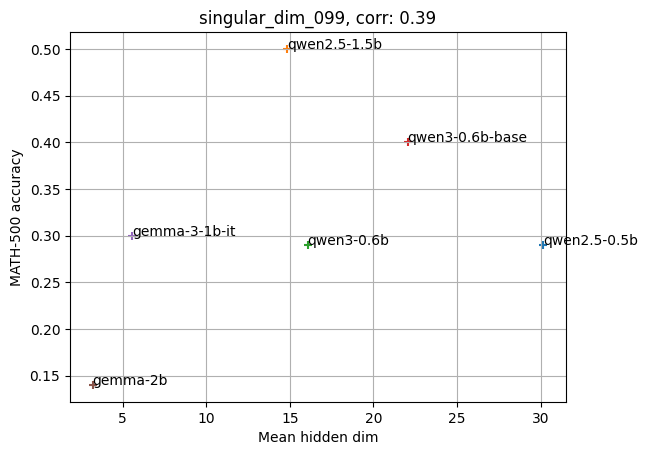

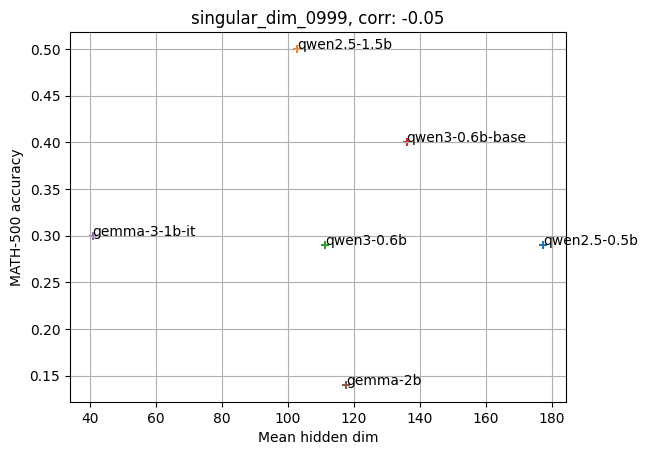

In [54]:
# Mean
for metric in ['singular_dim_09', 'singular_dim_095', 'singular_dim_099', 'singular_dim_0999']:
    for i, model in enumerate(model_names):
        plt.scatter(np.mean(model_stats[model][metric]), accs[model], marker='+')
        plt.text(np.mean(model_stats[model][metric]), accs[model], model)
    plt.grid()
    plt.ylabel('MATH-500 accuracy')
    plt.xlabel('Mean hidden dim')
    mean_dims = np.array([np.mean(model_stats[model][metric]) for model in model_names])
    model_accs = np.array([accs[model] for model in model_names])
    plt.title(f'{metric}, corr: {np.corrcoef(mean_dims, model_accs)[0, 1]:.2f}')
    plt.show()
    plt.close()

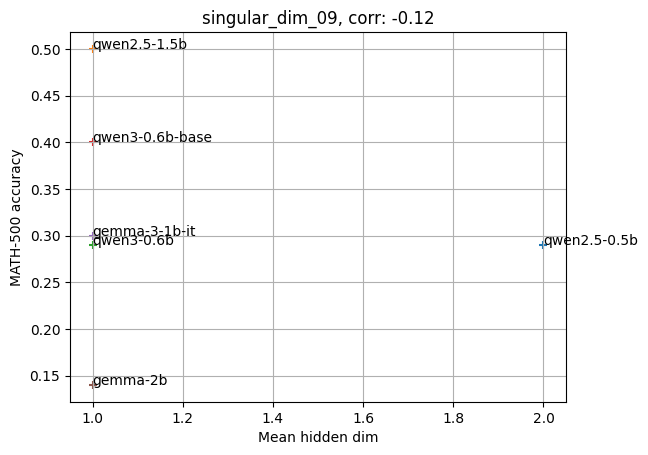

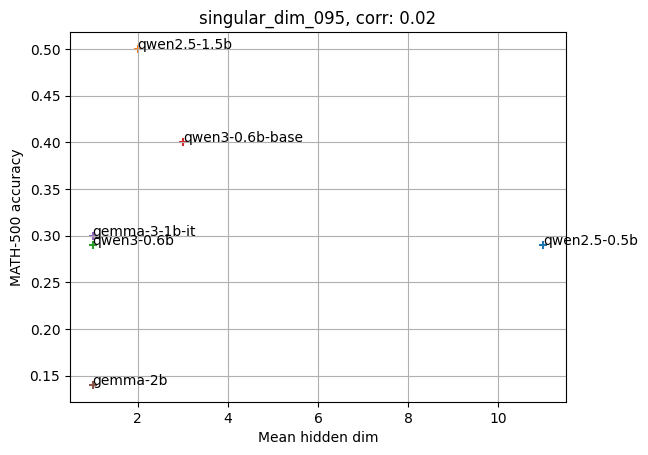

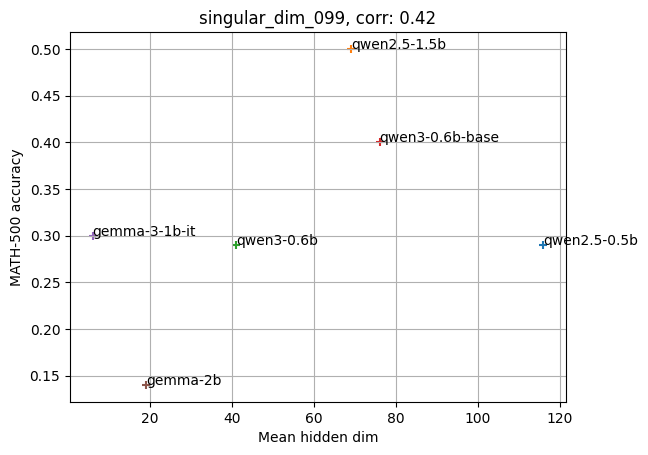

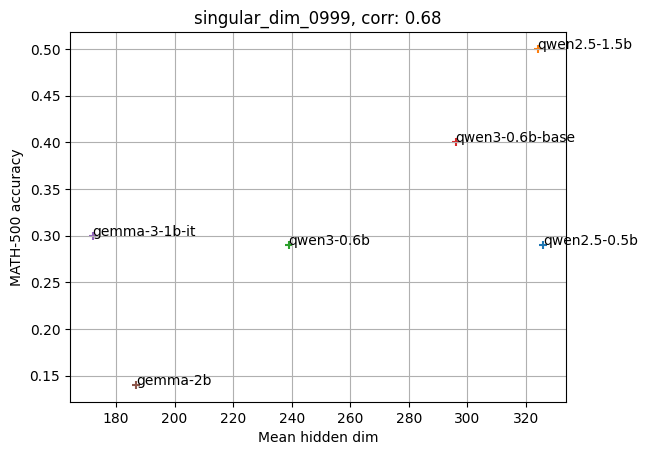

In [55]:
# Last
for metric in ['singular_dim_09', 'singular_dim_095', 'singular_dim_099', 'singular_dim_0999']:
    for i, model in enumerate(model_names):
        plt.scatter(model_stats[model][metric][-1], accs[model], marker='+')
        plt.text(model_stats[model][metric][-1], accs[model], model)
    plt.grid()
    plt.ylabel('MATH-500 accuracy')
    plt.xlabel('Mean hidden dim')
    last_dims = np.array([model_stats[model][metric][-1] for model in model_names])
    model_accs = np.array([accs[model] for model in model_names])
    plt.title(f'{metric}, corr: {np.corrcoef(last_dims, model_accs)[0, 1]:.2f}')
    plt.show()
    plt.close()